In [40]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import numpy as np
from linearmodels import PanelOLS
from validate import sammenlign_kommuner_for_dataframes

time_series = pd.read_csv("../data/processed/trivsel_fravaer_time_merged.csv")
uddannelse_time = pd.read_csv("../data/processed/uddannelse_score_time.csv")
time_series.head()

,kommune,klassetrin,skoleår,fravaer_pct,trivsel_score
0,Aabenraa,Mellemtrin,2019/2020,3.9,3.798601
1,Aabenraa,Mellemtrin,2020/2021,4.1,3.810850
2,Aabenraa,Mellemtrin,2021/2022,7.2,3.771528
3,Aabenraa,Mellemtrin,2022/2023,6.2,3.665700
4,Aabenraa,Mellemtrin,2023/2024,6.3,3.648550


In [41]:
trivsel_uddannelse_tid = time_series.merge(uddannelse_time, on=['kommune', 'klassetrin', 'skoleår'], how='inner')
print(trivsel_uddannelse_tid.shape)
trivsel_uddannelse_tid.head()

(1174, 6)


,kommune,klassetrin,skoleår,fravaer_pct,trivsel_score,foraeldre_uddannelsesniveau
0,Aabenraa,Mellemtrin,2019/2020,3.9,3.798601,4.925049
1,Aabenraa,Mellemtrin,2020/2021,4.1,3.810850,4.887460
2,Aabenraa,Mellemtrin,2021/2022,7.2,3.771528,4.853351
3,Aabenraa,Mellemtrin,2022/2023,6.2,3.665700,4.875839
4,Aabenraa,Mellemtrin,2023/2024,6.3,3.648550,4.853607


In [42]:
# Paneldata kræver at skoleår fungerer som index, så vi bruger startåret

trivsel_uddannelse_tid['skoleår'] = trivsel_uddannelse_tid['skoleår'].str[:4].astype(int)

Definer paneldata til fixed-effects-analyse

In [43]:
panel_df = trivsel_uddannelse_tid.set_index(['kommune', 'skoleår'])
display(panel_df.head())
print(panel_df.index.get_level_values('skoleår').value_counts().sort_index())



klassetrin  fravaer_pct  trivsel_score  \
kommune  skoleår                                           
Aabenraa 2019     Mellemtrin          3.9       3.798601   
         2020     Mellemtrin          4.1       3.810850   
         2021     Mellemtrin          7.2       3.771528   
         2022     Mellemtrin          6.2       3.665700   
         2023     Mellemtrin          6.3       3.648550   

                  foraeldre_uddannelsesniveau  
kommune  skoleår                               
Aabenraa 2019                        4.925049  
         2020                        4.887460  
         2021                        4.853351  
         2022                        4.875839  
         2023                        4.853607

skoleår
2019    196
2020    196
2021    194
2022    196
2023    196
2024    196
Name: count, dtype: int64


### Datavisualisering og deskriptiv statistik

In [44]:
plot_df = panel_df.reset_index()

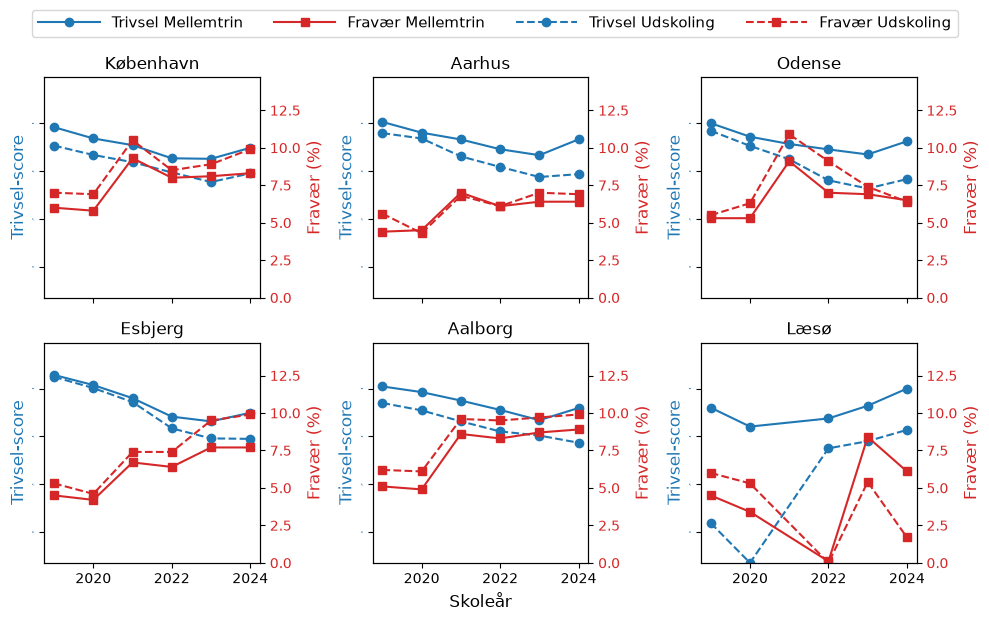

In [45]:
sample_kommuner = ['København', 'Aarhus', 'Odense', 'Esbjerg', 'Aalborg', 'Læsø']
linestyles = {'Mellemtrin': '-', 'Udskoling': '--'}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True)
axes = axes.flatten()

trivsel_min, trivsel_max = plot_df['trivsel_score'].min(), plot_df['trivsel_score'].max()
fravaer_min, fravaer_max = plot_df['fravaer_pct'].min(), plot_df['fravaer_pct'].max()

all_lines = []
all_labels = []

for i, kommune in enumerate(sample_kommuner):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    for klasse in ['Mellemtrin', 'Udskoling']:
        data = plot_df[(plot_df['kommune'] == kommune) & (plot_df['klassetrin'] == klasse)].sort_values('skoleår')

        line1, = ax1.plot(data['skoleår'], data['trivsel_score'], color='tab:blue', marker='o',
                           linestyle=linestyles[klasse], label=f'Trivsel {klasse}')
        line2, = ax2.plot(data['skoleår'], data['fravaer_pct'], color='tab:red', marker='s',
                           linestyle=linestyles[klasse], label=f'Fravær {klasse}')

        if i == 0:
            all_lines += [line1, line2]
            all_labels += [f'Trivsel {klasse}', f'Fravær {klasse}']

    ax1.set_title(kommune)
    ax1.set_ylabel('Trivsel-score', color='tab:blue',fontsize=12)
    ax2.set_ylabel('Fravær (%)', color='tab:red',fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue',labelsize=1)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(trivsel_min, trivsel_max)
    ax2.set_ylim(fravaer_min, fravaer_max)

axes[4].set_xlabel('Skoleår',fontsize=12)

fig.legend(all_lines, all_labels, loc='upper center', ncol=4, fontsize=11, bbox_to_anchor=(0.5, 1.04), handlelength=4)
fig.suptitle('', y=1.06)
plt.tight_layout()
plt.savefig('trivsel_fravaer_kommune_tidsserie.png', dpi=300, bbox_inches='tight')
plt.show()

Disse udvalgte kommuner udviser, med undtagelse af Læsø, en lignende udvikling i trivsel og fravær over tid, hvor fraværet stiger, mens trivslen falder. Der ses dog stadig en vis variation — flere kommuner (bl.a. Esbjerg og Odense) har en peak i fravær omkring 2021, hvilket kan hænge sammen med Covid-19, da fraværet efterfølgende aftager igen. På Læsø ses et afvigende mønster med en netto stigning i trivsel samt et fravær, der er tilnærmelsesvist konstant, bortset fra et markant dyk i 2022. Læsø mangler data for 2021, vi tjekker derfor om der andre kommuner hvor data mangler nogle af årene.

In [46]:
plot_df.groupby('skoleår')['kommune'].nunique()

skoleår
2019    98
2020    98
2021    97
2022    98
2023    98
2024    98
Name: kommune, dtype: int64

In [47]:
sammenlign_kommuner_for_dataframes({2020: plot_df[plot_df['skoleår'] == 2020], 2021: plot_df[plot_df['skoleår'] == 2021]})

Kommuner i alt (union): 98
Kommuner fælles for alle datasæt: 97

⚠️  1 kommune(r) findes ikke i alle datasæt:
  - Læsø: findes i [2020], mangler i [2021]


{'Læsø'}

Det eneste manglende data er for Læsø kommune i 2021. Dette skyldes sandsynligvis diskretionering grundet det lille elevtal.  

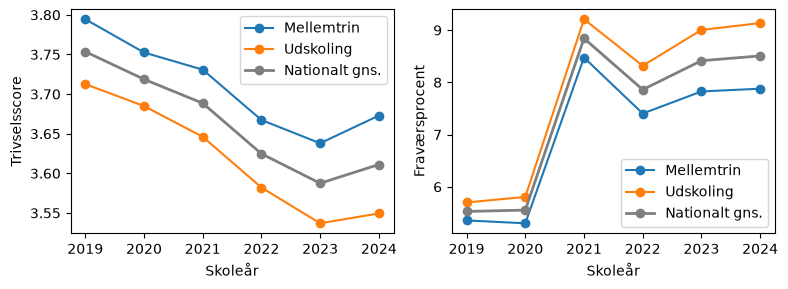

In [48]:
national_by_klasse = plot_df.groupby(['skoleår', 'klassetrin'])[['trivsel_score', 'fravaer_pct']].mean().reset_index()
national = plot_df.groupby('skoleår')[['trivsel_score', 'fravaer_pct']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
for klasse, color in zip(['Mellemtrin', 'Udskoling'], ['tab:blue', 'tab:orange']):
    data = national_by_klasse[national_by_klasse['klassetrin'] == klasse]
    ax1.plot(data['skoleår'], data['trivsel_score'], marker='o', label=klasse, color=color)
    ax2.plot(data['skoleår'], data['fravaer_pct'], marker='o', label=klasse, color=color)

ax1.plot(national['skoleår'], national['trivsel_score'], color='tab:grey', marker='o', linewidth=2, label='Nationalt gns.')
ax2.plot(national['skoleår'], national['fravaer_pct'], color='tab:grey', marker='o', linewidth=2, label='Nationalt gns.')

ax1.set_xlabel('Skoleår'); ax1.set_ylabel('Trivselsscore'); ax1.legend()
ax2.set_xlabel('Skoleår'); ax2.set_ylabel('Fraværsprocent'); ax2.legend()
plt.tight_layout()

plt.savefig('trivsel_fravaer_gennemsnit_tidsserie.png', dpi=300, bbox_inches='tight')
plt.show()

Dette plot viser at tidsudviklingen følger samme tendens for mellemtrin og udskoling, men at udgangspunktet er at udskolingen har et højere fravær og en lavere trivsel end mellemtrinnet. 

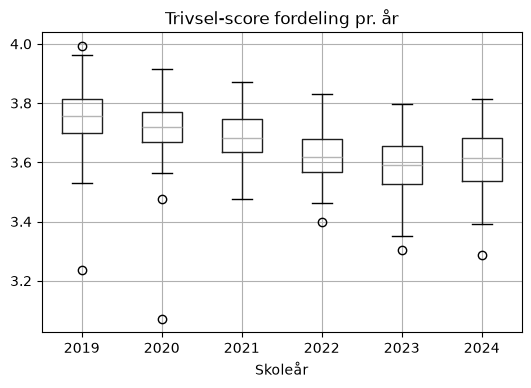

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_df.boxplot(column='trivsel_score', by='skoleår', ax=ax)
plt.title('Trivsel-score fordeling pr. år')
plt.suptitle('')
plt.xlabel('Skoleår')
plt.show()

Boxplottene viser en svagt faldende median trivsel-score fra 2019 til 2024, mens spredningen (IQR) mellem kommunerne forbliver forholdsvis konstant på tværs af årene. Der ses enkelte outlier-kommuner med lav trivsel i stort set alle år, uden en tydelig stigning i antallet af outliers i Covid-årene 2020/2021.

#### Variansanalyse (total, between, within) for trivsel, fravær og forældres uddannelsesniveau

In [50]:

for var in ['trivsel_score', 'fravaer_pct', 'foraeldre_uddannelsesniveau']:
    total_var = panel_df[var].var()
    between_var = panel_df.groupby('kommune')[var].mean().var()
    
    kommune_level = panel_df.index.get_level_values('kommune')
    within_var = (panel_df[var] - panel_df[var].groupby(kommune_level).transform('mean')).var()
    
    print(f"{var}:")
    print(f"  Total varians:    {total_var:.4f}")
    print(f"  Between varians:  {between_var:.4f}")
    print(f"  Within varians:   {within_var:.4f}")
    print(f"  Within/Total:     {within_var/total_var:.2%}\n")

trivsel_score:
  Total varians:    0.0110
  Between varians:  0.0032
  Within varians:   0.0079
  Within/Total:     71.37%

fravaer_pct:
  Total varians:    3.9677
  Between varians:  1.2314
  Within varians:   2.7649
  Within/Total:     69.69%

foraeldre_uddannelsesniveau:
  Total varians:    0.1607
  Between varians:  0.1556
  Within varians:   0.0064
  Within/Total:     4.00%



Samme analyse, opdelt i skoletrin

In [51]:
for klasse in ['Mellemtrin', 'Udskoling']:
    print(f"=== {klasse} ===")
    data = panel_df[panel_df['klassetrin'] == klasse] if 'klassetrin' in panel_df.columns else panel_df.xs(klasse, level='klassetrin')
    
    for var in ['trivsel_score', 'fravaer_pct', 'foraeldre_uddannelsesniveau']:
        total_var = data[var].var()
        between_var = data.groupby('kommune')[var].mean().var() if 'kommune' in data.columns else data.groupby(level='kommune')[var].mean().var()
        kommune_level = data.index.get_level_values('kommune') if data.index.nlevels > 1 else data['kommune']
        within_var = (data[var] - data[var].groupby(kommune_level).transform('mean')).var()
        
        print(f"{var}: within/total = {within_var/total_var:.2%}")
    print()

=== Mellemtrin ===
trivsel_score: within/total = 53.17%
fravaer_pct: within/total = 64.61%
foraeldre_uddannelsesniveau: within/total = 1.71%

=== Udskoling ===
trivsel_score: within/total = 62.54%
fravaer_pct: within/total = 66.76%
foraeldre_uddannelsesniveau: within/total = 3.95%



Variansanalysen viser at for trivsel og fravær udgør variansen indenfor kommunerne over tid størstedelen af den totale varians, mens det for forældres uddannelsesniveau i stedet er tilfældet at variansen er størst mellem kommunerne. Dette stemmer overens med at uddannelsesniveauet kun ændres meget langsomt over tid, mens der kan være store variationer på tværs af kommuner. 

En opdeling af variansanalysen på skoletrin viser, at mellemtrinnet har en lavere andel af within-varians for trivsel end udskolingen (53 % mod 63 %), men at den generelle tendens for den poolede data holder når der opdeles efter skoletrin. 

## Lineær regression, ændring i fravær vs. ændring i trivsel

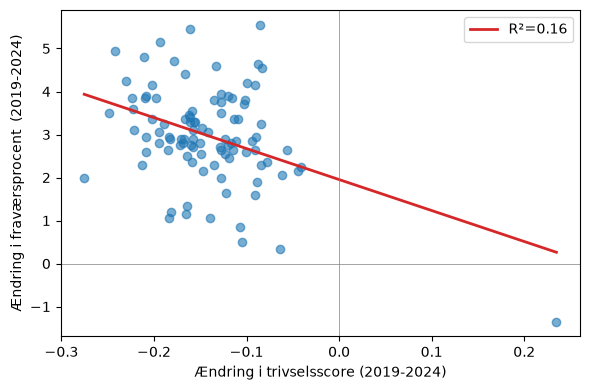

                            OLS Regression Results                            
Dep. Variable:        fravaer_ændring   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     18.07
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           4.93e-05
Time:                        15:25:40   Log-Likelihood:                -140.96
No. Observations:                  98   AIC:                             285.9
Df Residuals:                      96   BIC:                             291.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.9532      0.263     

In [52]:
# Ændring i trivsel og fravær fra første til sidste år i datasættet per kommune, dvs. midlet over klassetrin
yearly = plot_df.groupby(['kommune', 'skoleår'])[['trivsel_score', 'fravaer_pct']].mean().reset_index()

first_year = yearly['skoleår'].min()
last_year = yearly['skoleår'].max()

first = yearly[yearly['skoleår'] == first_year].set_index('kommune')
last = yearly[yearly['skoleår'] == last_year].set_index('kommune')

change = pd.DataFrame({
    'trivsel_ændring': last['trivsel_score'] - first['trivsel_score'],
    'fravaer_ændring': last['fravaer_pct'] - first['fravaer_pct']
}).dropna()

plt.figure(figsize=(6, 4))
plt.scatter(change['trivsel_ændring'], change['fravaer_ændring'], alpha=0.6)

# regression line
X = sm.add_constant(change['trivsel_ændring'])
model = sm.OLS(change['fravaer_ændring'], X).fit()
x_range = np.linspace(change['trivsel_ændring'].min(), change['trivsel_ændring'].max(), 100)
y_pred = model.params['const'] + model.params['trivsel_ændring'] * x_range
plt.plot(x_range, y_pred, color='tab:red', linewidth=2, label=f"R²={model.rsquared:.2f}")

plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.xlabel(f'Ændring i trivselsscore ({first_year}-{last_year})')
plt.ylabel(f'Ændring i fraværsprocent  ({first_year}-{last_year})')
#plt.title('Ændring i trivsel vs. ændring i fravær, pr. kommune')
plt.legend()
plt.tight_layout()
plt.savefig('trivsel_fravaer_ændring_scatter.png', dpi=350)
plt.show()

print(model.summary())

In [53]:
change[(change['trivsel_ændring'] > 0) & (change['fravaer_ændring'] < 0)]

,trivsel_ændring,fravaer_ændring
kommune,,
Læsø,0.234719,-1.35


Alle kommuner med undtagelse af Læsø har oplevet et netto fald i trivsel og en stigning i fravær fra 2019/2020 til 2024/2025. Selvom den lineære regression har R^2=0.158 og p<0.001, bør det tjekkes om outlieren, som er Læsø, overdriver den lineære tendens. Da Læsø er en meget lille kommune kan der være meget støj på data, og derfor bør den ikke bære hele regressionen i sig selv. 

In [54]:
#Regression uden outlier

change_no_outlier = change[(change['trivsel_ændring'] < 0) & (change['fravaer_ændring'] > 0)]  # drops the ~0.23 point

X = sm.add_constant(change_no_outlier['trivsel_ændring'])
model_no_outlier = sm.OLS(change_no_outlier['fravaer_ændring'], X).fit()
print(model_no_outlier.summary())

                            OLS Regression Results                            
Dep. Variable:        fravaer_ændring   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     4.428
Date:                Wed, 22 Jul 2026   Prob (F-statistic):             0.0380
Time:                        15:25:41   Log-Likelihood:                -137.92
No. Observations:                  97   AIC:                             279.8
Df Residuals:                      95   BIC:                             285.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.3673      0.328     

Når Læsø ikke inkluderes i regressionen falder R^2 til 0.045, altså langt mindre forklaringsgrad, samtidig med at p-værdien stiger til 0.04, resultatet forbliver dog statistisk signifikant med p<0.05. Den lineære koefficient faldt også fra -7,2 til -4,5, hvilket igen indikerer at tendensen for alle de andre kommuner er mindre udtalt. 

#### Spearmans rangkorrelation

In [55]:
from scipy import stats
rho, p = stats.spearmanr(change['trivsel_ændring'], change['fravaer_ændring'])
print(f"Spearman's rho = {rho:.3f}, p = {p:.4f}")

Spearman's rho = -0.252, p = 0.0124


En Spearman-rangkorrelation (som er robust over for ekstreme værdier) bekræfter en svag til moderat negativ sammenhæng (ρ=-0,25, p=0,012), hvilket stemmer bedst overens med OLS-resultatet uden den mest ekstreme kommune. Samlet set peger analyserne på en reel, men beskeden sammenhæng mellem ændring i trivsel og ændring i fravær på tværs af kommuner i perioden

### Fixed-effects-analyse

Vi udfører en fixed-effects-analyse hvor vi undersøger afvigelser fra hver kommunes gennemsnitlige værdier over tid mens statiske effekter som f.eks. kan skyldes geografi, indkomstniveau osv. ignoreres. På den måde tager vi højde for eventuelle tidskonstante confounders uden at specificere hvad de måtte være, og laver multipel regression for fravær som funktion af trivsel og forældres uddannelsesniveau. 

Det er vigtigt at understrege, at Covid-19 i høj grad påvirkede både trivsel og fravær i årene 2020-2022, og at denne påvirkning var fælles for alle kommuner. Da vores fixed-effects-model kun kontrollerer for tidskonstante forhold, ikke for forhold der varierer over tid og rammer alle kommuner samtidig, kan Covid-perioden potentielt forstyrre estimatet. Resultatet bør derfor tolkes med forbehold, medmindre der kontrolleres for dette, f.eks. ved at tilføje "TimeEffects" til modellen.

In [56]:
model = PanelOLS.from_formula(
    'fravaer_pct ~ trivsel_score + foraeldre_uddannelsesniveau + EntityEffects',
    data=panel_df
)
results = model.fit()
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:            fravaer_pct   R-squared:                        0.4123
Estimator:                   PanelOLS   R-squared (Between):             -16.457
No. Observations:                1174   R-squared (Within):               0.4123
Date:                Wed, Jul 22 2026   R-squared (Overall):             -15.659
Time:                        15:25:41   Log-likelihood                   -1950.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      376.67
Entities:                          98   P-value                           0.0000
Avg Obs:                       11.980   Distribution:                  F(2,1074)
Min Obs:                      10.0000                                           
Max Obs:                       12.000   F-statistic (robust):             376.67
                            

R²-værdien på 0,41 fortæller, at modellen forklarer 41 % af variationen inden for en kommune over tid. Koefficienten for trivsel er stor og negativ (-11,4) og statistisk signifikant (p<0,0001). Vi ser altså en generel tendens til, at stigende trivsel er forbundet med et fald i fravær. Koefficienten for forældres uddannelsesniveau er positiv og statistisk signifikant, hvilket er i modstrid med hypotesen om, at et højere uddannelsesniveau fører til mindre fravær. Det er også i uoverensstemmelse med det tidligere resultat fra vores multiple regression med data fra 2024/2025, hvor vi så, at der ikke var en statistisk signifikant effekt af forældrenes uddannelsesniveau. Det er muligt, at resultatet i stedet skyldes en fælles, landsdækkende og tidsafhængig effekt, f.eks. stigende fravær som følge af Covid-19.

En F-test for poolability (p<0,0001) bekræfter, at der er signifikant variation mellem kommunerne (og årene), som retfærdiggør brugen af fixed effects frem for en simpel poolet regression.

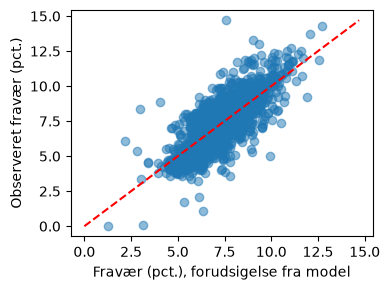

In [57]:
full_fitted = (results.fitted_values['fitted_values'] + results.estimated_effects['estimated_effects']).values

plt.figure(figsize=(4, 3))
plt.scatter(full_fitted, panel_df['fravaer_pct'], alpha=0.5)

lims = [panel_df['fravaer_pct'].min(), panel_df['fravaer_pct'].max()]
plt.plot(lims, lims, color='red', linestyle='--')

plt.xlabel('Fravær (pct.), forudsigelse fra model')
plt.ylabel('Observeret fravær (pct.)')
plt.tight_layout()
plt.savefig('fravaer_obs_vs_fit.png', dpi=350)
plt.show()

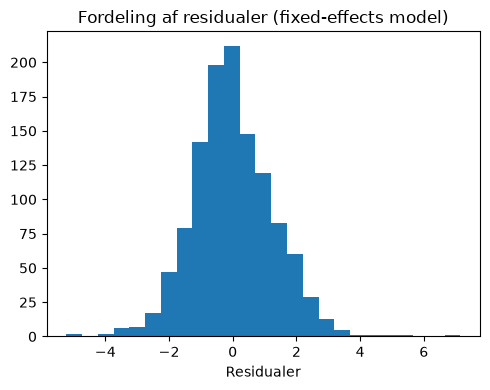

In [58]:
#Residualer

residuals = results.resids  # linearmodels stores these directly

plt.figure(figsize=(5, 4))
plt.hist(residuals, bins=25)
plt.xlabel('Residualer')
plt.title('Fordeling af residualer (fixed-effects model)')
plt.tight_layout()
plt.show()


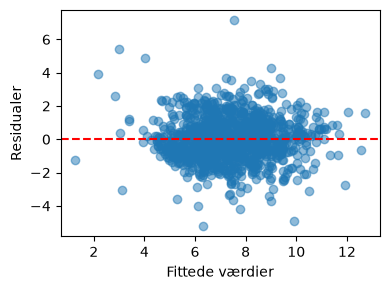

In [59]:
plt.figure(figsize=(4, 3))
plt.scatter(full_fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fittede værdier')
plt.ylabel('Residualer')
plt.tight_layout()
plt.savefig('residualer.png', dpi=350)
plt.show()

#### Two-way fixed-effects-analyse

For at undersøge påvirkningen af landsdækkende effekter såsom Covid-19 på modellen, afslutter vi analysen med at lave en two-way-model som udover at fratrække konstante effekter indenfor hver kommune også absorberer nationale effekter over tid som er fælles på tværs af kommunerne. Den tilbageværende variation kan dermed tilskrives reel variation i hver kommune over tid. 

In [60]:
model_twoway = PanelOLS.from_formula(
    'fravaer_pct ~ trivsel_score + foraeldre_uddannelsesniveau + EntityEffects + TimeEffects',
    data=panel_df
)
results_twoway = model_twoway.fit(cov_type='clustered', cluster_entity=True)
print(results_twoway)

                          PanelOLS Estimation Summary                           
Dep. Variable:            fravaer_pct   R-squared:                        0.1862
Estimator:                   PanelOLS   R-squared (Between):             -14.709
No. Observations:                1174   R-squared (Within):               0.3026
Date:                Wed, Jul 22 2026   R-squared (Overall):             -14.000
Time:                        15:25:43   Log-likelihood                   -1463.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      122.27
Entities:                          98   P-value                           0.0000
Avg Obs:                       11.980   Distribution:                  F(2,1069)
Min Obs:                      10.0000                                           
Max Obs:                       12.000   F-statistic (robust):             99.677
                            

Den relevante R²-værdi (Within R²) er nu faldet til 0,30, hvilket er forventeligt, da vi har fjernet endnu en kilde til variation fra modellen (den fælles nationale tidstrend). Koefficienten for trivsel er stadig statistisk signifikant og negativ, om end den er faldet betydeligt i størrelse (fra -11,4 til -6,2). Dette indikerer, at en del af den oprindelige sammenhæng skyldtes en fælles national tendens, men at der stadig er en reel, betydelig sammenhæng mellem trivsel og fravær inden for den enkelte kommune, når både kommune- og årsspecifikke forhold kontrolleres for. Mere bemærkelsesværdigt er det, at koefficienten for forældres uddannelsesniveau nu er tæt på nul og ikke længere statistisk signifikant (p=0,93). Dette understøtter hypotesen om, at den tidligere observerede sammenhæng mellem uddannelsesniveau og fravær i højere grad skyldtes Covid-19 end en reel, direkte effekt.

### Undersøgelse af trivsel/fravær-forholdets afhængighed af skoletrin

Analysen har indtil videre ikke taget højde for at data er delt op i skoletrin, mellemtrin/udskoling, men blot behandlet al data samlet. Da vi tidligere så at de to skoletrin udviste forskellige tendenser i forholdet mellem trivsel og fravær, er det relevant at undersøge om en opdeling i skoletrin påvirker resultatet af analysen

In [61]:
for gruppe in ['Mellemtrin', 'Udskoling']:
    data_gruppe = panel_df[panel_df['klassetrin'] == gruppe]
    
    model = PanelOLS.from_formula(
        'fravaer_pct ~ trivsel_score + foraeldre_uddannelsesniveau + EntityEffects + TimeEffects',
        data=data_gruppe
    )
    results = model.fit(cov_type='clustered', cluster_entity=True)
    print(f"--- {gruppe} ---")
    print(results)
    print()

--- Mellemtrin ---
                          PanelOLS Estimation Summary                           
Dep. Variable:            fravaer_pct   R-squared:                        0.0006
Estimator:                   PanelOLS   R-squared (Between):              0.4504
No. Observations:                 587   R-squared (Within):              -0.0144
Date:                Wed, Jul 22 2026   R-squared (Overall):              0.4337
Time:                        15:25:43   Log-likelihood                   -499.53
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.1490
Entities:                          98   P-value                           0.8616
Avg Obs:                       5.9898   Distribution:                   F(2,482)
Min Obs:                       5.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             0.0807
         

Resultatet for udskolingen følger samme tendens som den tidligere analyse hvor vi ikke skelnede mellem skoletrin, idet der ses en statistisk signifikant sammenhæng, p<0.005, mellem stigende trivsel og faldende fravær, men ingen statistisk signifikant sammenhæng mellem fravær og forældrenes uddannelsesniveau. Derudover finder vi igen en tilsvarende værdi på R^2=0.33
For mellemtrinnet er dette imidlertid ikke tilfældet, idet vi får en negativ værdi af R^2, hvilket fortæller at modellen er dårligere til at forklare variationen i kommunerne over tid end hvis vi blot benyttede det kommunale gennemsnit. Denne two-way fixed-effects-model er altså ikke meningsfuld i dette tilfælde. Dette kan skyldes at vi kun har 587 observationer og fjerner det kommunale gennemsnit samt det nationale gennemsnit for hvert år fra modellen, altså 98 + 6 =104 frihedsgrader. Hvis der ikke er tilstrækkelig tilbageværende variation i data giver modellen ikke meningsfulde resultater, hvilket tilsyneladende er tilfældet her. Dette illustrerer en generel afvejning i paneldata-analyser: jo flere faste effekter og undergrupper man inkluderer, jo mindre variation er der tilbage at estimere fra, hvilket kan gøre modellen underpowered.

En yderligere opdeling af paneldata-analysen på skoletrin viser, at den nuværende datamængde ikke er tilstrækkelig til at understøtte en så detaljeret two-way fixed-effects-model for mellemtrinnet. En mere fintmasket analyse ville kræve enten flere år med data eller en anden modelspecifikation (f.eks. one-way fixed effects), hvilket vi ikke forfølger yderligere her.